# Exploratory Data Analysis

Explore the characteristics associated with serious mortgage delinquency within the first 24 months.

This notebook uses the corrected calendar-based 24-month target created in `01_data_ingestion.ipynb`. Associations are descriptive and should not be interpreted as causal effects.


## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
model_data = pd.read_parquet(
    "../data/processed/model_data_2019.parquet"
)

model_data.shape

(49897, 31)

In [3]:
model_data.head()

,credit_score,first_payment_date,first_time_homebuyer,maturity_date,msa,mi_percent,num_units,occupancy_status,cltv,dti,...,original_loan_term,num_borrowers,seller_name,super_conforming_flag,special_eligibility_program,harp_indicator,property_valuation_method,interest_only_indicator,first_payment_month,seriously_delinquent_24m
0,741.0,201903,N,204902,NaN,0,1,P,80.0,33.0,...,360,2,OTHER,N,None,N,NaN,N,2019-03-01,False
1,731.0,201903,N,204902,13460.0,0,1,P,77.0,44.0,...,360,1,OTHER,N,None,N,NaN,N,2019-03-01,False
2,722.0,201903,N,204902,NaN,30,1,P,95.0,41.0,...,360,2,OTHER,N,None,N,NaN,N,2019-03-01,False
3,729.0,201903,N,204902,NaN,25,1,P,87.0,17.0,...,360,1,OTHER,N,None,N,NaN,N,2019-03-01,False
4,773.0,201903,N,204902,33700.0,0,1,P,29.0,43.0,...,360,2,OTHER,N,None,N,NaN,N,2019-03-01,False


## 2. Target Distribution

In [4]:
target_counts = model_data["seriously_delinquent_24m"].value_counts()
target_rate = model_data["seriously_delinquent_24m"].mean()

print(target_counts)
print(f"\nSerious delinquency rate: {target_rate:.2%}")

seriously_delinquent_24m
False    47612
True      2285
Name: count, dtype: int64

Serious delinquency rate: 4.58%


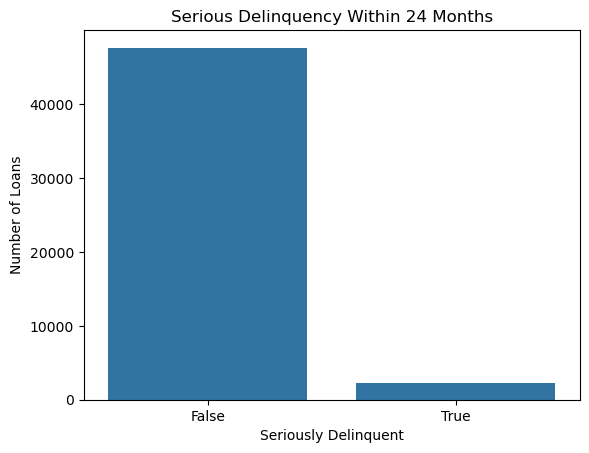

In [5]:
sns.countplot(
    data=model_data,
    x="seriously_delinquent_24m"
)

plt.title("Serious Delinquency Within 24 Months")
plt.xlabel("Seriously Delinquent")
plt.ylabel("Number of Loans")
plt.show()

## 3. Borrower Risk Characteristics

### 3.1 Debt-to-Income Ratio


**Hypothesis:** Higher DTI may be associated with greater serious delinquency risk, particularly among borrowers with weaker credit scores.

In [6]:
model_data["dti"].describe()

count    49866.000000
mean        35.306080
std          9.373626
min          1.000000
25%         29.000000
50%         37.000000
75%         43.000000
max         50.000000
Name: dti, dtype: float64

In [7]:
model_data.groupby("seriously_delinquent_24m")["dti"].mean()

seriously_delinquent_24m
False    35.128633
True     39.007891
Name: dti, dtype: float64

In [8]:
model_data["dti_group"] = pd.cut(
    model_data["dti"],
    bins=[0, 20, 30, 40, 50],
    labels=["1-20", "21-30", "31-40", "41-50"]
)

In [9]:
dti_risk = (
    model_data.groupby("dti_group", observed=True)
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

dti_risk

,count,mean
dti_group,,
1-20,3854,0.015309
21-30,11107,0.025209
31-40,17355,0.044080
41-50,17550,0.067066


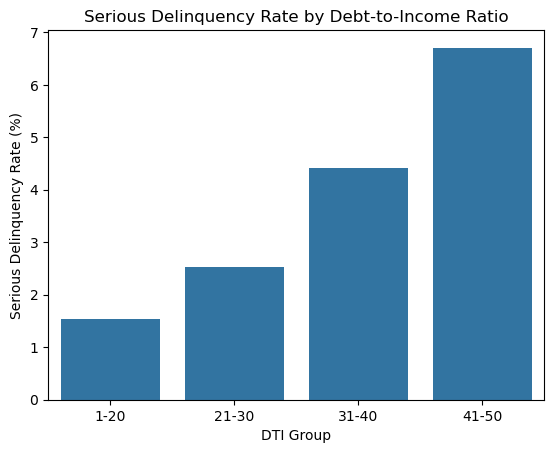

In [10]:
dti_risk_plot = dti_risk.reset_index()
dti_risk_plot["delinquency_rate"] = dti_risk_plot["mean"] * 100

sns.barplot(
    data=dti_risk_plot,
    x="dti_group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Debt-to-Income Ratio")
plt.xlabel("DTI Group")
plt.ylabel("Serious Delinquency Rate (%)")
plt.show()

### 3.2 Credit Score

In [11]:
model_data["credit_score"].describe()

count    49880.000000
mean       749.459202
std         43.980867
min        562.000000
25%        720.000000
50%        757.000000
75%        785.000000
max        832.000000
Name: credit_score, dtype: float64

In [12]:
model_data["credit_score_group"] = pd.cut(
    model_data["credit_score"],
    bins=[0, 650, 700, 750, 800, 850],
    labels=["<650", "650-699", "700-749", "750-799", "800+"],
    right=False
)

In [13]:
credit_risk = (
    model_data.groupby("credit_score_group", observed=True)
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

credit_risk

,count,mean
credit_score_group,,
<650,1201,0.117402
650-699,6237,0.087702
700-749,14574,0.060382
750-799,22188,0.028935
800+,5680,0.013028


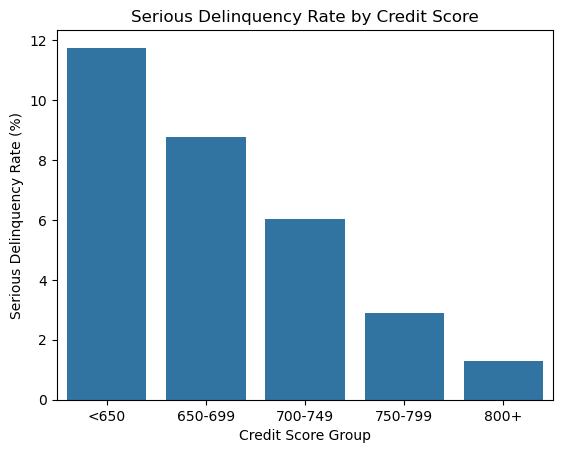

In [14]:
credit_risk_plot = credit_risk.reset_index()
credit_risk_plot["delinquency_rate"] = credit_risk_plot["mean"] * 100

sns.barplot(
    data=credit_risk_plot,
    x="credit_score_group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Credit Score")
plt.xlabel("Credit Score Group")
plt.ylabel("Serious Delinquency Rate (%)")
plt.show()

### 3.3 DTI and Credit Score Interaction

In [15]:
dti_credit_risk = (
    model_data.groupby(
        ["credit_score_group", "dti_group"],
        observed=True
    )["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

dti_credit_risk

count      mean
credit_score_group dti_group                 
<650               1-20          46  0.065217
                   21-30        210  0.109524
                   31-40        490  0.112245
                   41-50        451  0.130820
650-699            1-20         255  0.050980
                   21-30       1033  0.057115
                   31-40       2363  0.079983
                   41-50       2578  0.110939
700-749            1-20         710  0.036620
                   21-30       2755  0.034846
                   31-40       5312  0.054405
                   41-50       5789  0.080843
750-799            1-20        2075  0.005783
                   21-30       5484  0.017141
                   31-40       7437  0.028103
                   41-50       7185  0.045233
800+               1-20         767  0.006519
                   21-30       1620  0.004321
                   31-40       1746  0.013173
                   41-50       1543  0.025275

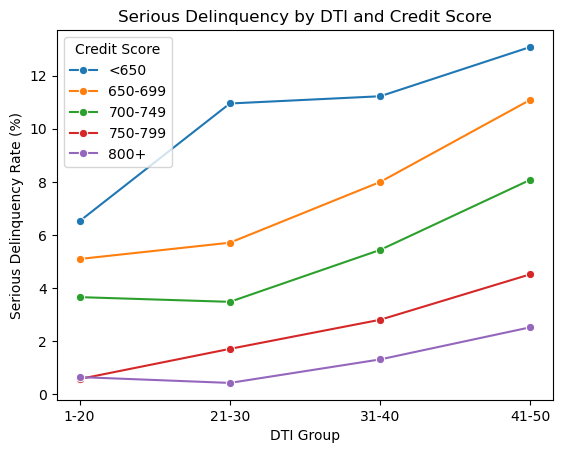

In [16]:
interaction_plot = (
    dti_credit_risk
    .reset_index()
)

interaction_plot["delinquency_rate"] = (
    interaction_plot["mean"] * 100
)

sns.lineplot(
    data=interaction_plot,
    x="dti_group",
    y="delinquency_rate",
    hue="credit_score_group",
    marker="o"
)

plt.title("Serious Delinquency by DTI and Credit Score")
plt.xlabel("DTI Group")
plt.ylabel("Serious Delinquency Rate (%)")
plt.legend(title="Credit Score")
plt.show()

### 3.4 Combined Loan-to-Value Ratio

In [17]:
model_data["cltv"].describe()

count    49896.000000
mean        75.807780
std         16.812743
min          5.000000
25%         69.000000
50%         80.000000
75%         90.000000
max        105.000000
Name: cltv, dtype: float64

In [18]:
model_data["cltv_group"] = pd.cut(
    model_data["cltv"],
    bins=[0, 60, 70, 80, 90, 100, float("inf")],
    labels=["≤60", "61-70", "71-80", "81-90", "91-100", ">100"],
    right=True
)

In [19]:
cltv_risk = (
    model_data.groupby("cltv_group", observed=True)
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

cltv_risk

,count,mean
cltv_group,,
≤60,8826,0.029232
61-70,5516,0.040790
71-80,19120,0.041318
81-90,6631,0.052632
91-100,9664,0.067156
>100,139,0.093525


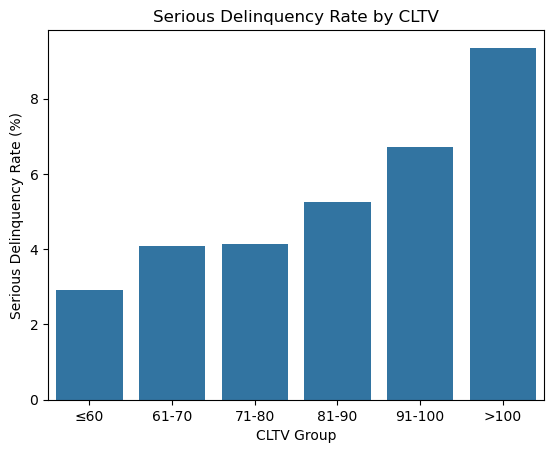

In [20]:
cltv_risk_plot = cltv_risk.reset_index()
cltv_risk_plot["delinquency_rate"] = cltv_risk_plot["mean"] * 100

sns.barplot(
    data=cltv_risk_plot,
    x="cltv_group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by CLTV")
plt.xlabel("CLTV Group")
plt.ylabel("Serious Delinquency Rate (%)")
plt.show()

## 4. Loan Characteristics

### 4.1 Loan Purpose

In [21]:
model_data["loan_purpose"].value_counts(dropna=False)

loan_purpose
P    27704
N    11647
C    10546
Name: count, dtype: int64

In [22]:
loan_purpose_risk = (
    model_data.groupby("loan_purpose")
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

loan_purpose_risk

,count,mean
loan_purpose,,
C,10546,0.048834
P,27704,0.046925
N,11647,0.040354


### 4.2 Occupancy Status

In [23]:
model_data["occupancy_status"].value_counts(dropna=False)

occupancy_status
P    44512
I     3405
S     1980
Name: count, dtype: int64

In [24]:
occupancy_risk = (
    model_data.groupby("occupancy_status")
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

occupancy_risk

,count,mean
occupancy_status,,
I,3405,0.051101
P,44512,0.045830
S,1980,0.035859


### 4.3 Original Interest Rate

In [25]:
model_data["original_interest_rate"].describe()

count    49897.000000
mean         4.237058
std          0.585905
min          2.350000
25%          3.875000
50%          4.125000
75%          4.625000
max          6.750000
Name: original_interest_rate, dtype: float64

In [26]:
model_data["interest_rate_group"] = pd.cut(
    model_data["original_interest_rate"],
    bins=[0, 3.5, 4.0, 4.5, 5.0, 5.5, 7.0],
    labels=["<3.5", "3.5-3.99", "4.0-4.49", "4.5-4.99", "5.0-5.49", "5.5+"],
    right=False
)

interest_rate_risk = (
    model_data.groupby("interest_rate_group", observed=True)
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

interest_rate_risk

,count,mean
interest_rate_group,,
<3.5,3484,0.024397
3.5-3.99,15950,0.037931
4.0-4.49,13540,0.044313
4.5-4.99,12104,0.053453
5.0-5.49,3056,0.067081
5.5+,1763,0.081112


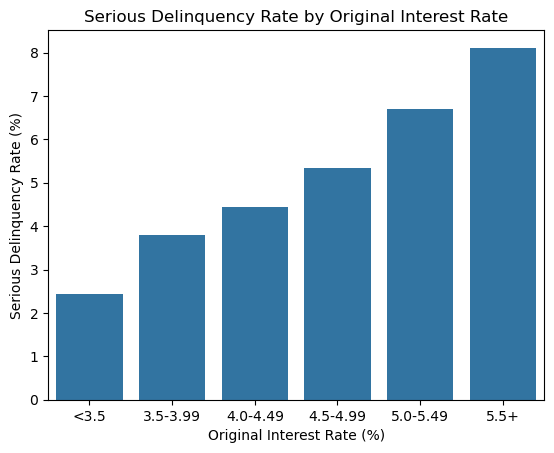

In [27]:
interest_rate_risk_plot = interest_rate_risk.reset_index()
interest_rate_risk_plot["delinquency_rate"] = (
    interest_rate_risk_plot["mean"] * 100
)

sns.barplot(
    data=interest_rate_risk_plot,
    x="interest_rate_group",
    y="delinquency_rate"
)

plt.title("Serious Delinquency Rate by Original Interest Rate")
plt.xlabel("Original Interest Rate (%)")
plt.ylabel("Serious Delinquency Rate (%)")
plt.show()

### 4.4 Number of Borrowers

In [28]:
model_data["num_borrowers"].value_counts(dropna=False).sort_index()

num_borrowers
1    26877
2    22521
3      451
4       47
5        1
Name: count, dtype: int64

In [29]:
borrower_risk = (
    model_data.groupby("num_borrowers", observed=True)
    ["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

borrower_risk

,count,mean
num_borrowers,,
1,26877,0.054098
2,22521,0.035478
3,451,0.059867
4,47,0.106383
5,1,0.000000


## 5. Multivariable Risk Patterns

### 5.1 Interest Rate and Credit Score

Is a higher original interest rate associated with greater delinquency risk even among borrowers with similar credit scores?

In [30]:
rate_credit_risk = (
    model_data.groupby(
        ["credit_score_group", "interest_rate_group"],
        observed=True
    )["seriously_delinquent_24m"]
    .agg(["count", "mean"])
)

rate_credit_risk

count      mean
credit_score_group interest_rate_group                 
<650               <3.5                    44  0.068182
                   3.5-3.99               148  0.114865
                   4.0-4.49               221  0.095023
                   4.5-4.99               389  0.136247
                   5.0-5.49               192  0.093750
                   5.5+                   207  0.140097
650-699            <3.5                   244  0.057377
                   3.5-3.99              1116  0.072581
                   4.0-4.49              1404  0.085470
                   4.5-4.99              2026  0.092300
                   5.0-5.49               852  0.102113
                   5.5+                   595  0.097479
700-749            <3.5                   695  0.041727
                   3.5-3.99              4426  0.056258
                   4.0-4.49              4135  0.059492
                   4.5-4.99              3978  0.063851
                   5.0-5.49               932  0.075107
                   5.5+                   408  0.078431
750-799            <3.5                  1906  0.017838
                   3.5-3.99              8108  0.029107
                   4.0-4.49              6195  0.030186
                   4.5-4.99              4662  0.029172
                   5.0-5.49               872  0.032110
                   5.5+                   445  0.047191
800+               <3.5                   593  0.008432
                   3.5-3.99              2150  0.009767
                   4.0-4.49              1579  0.016466
                   4.5-4.99              1043  0.016299
                   5.0-5.49               208  0.009615
                   5.5+                   107  0.028037

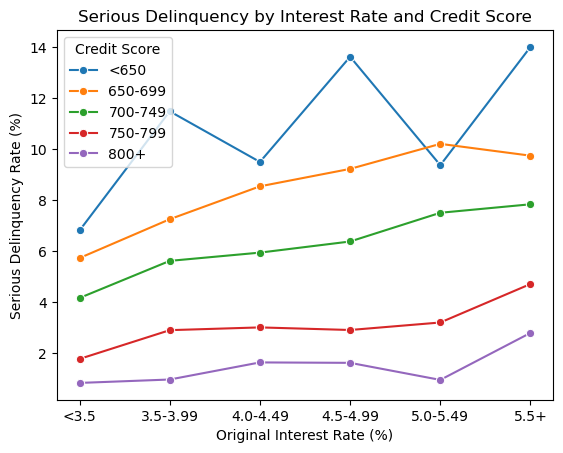

In [31]:
rate_credit_plot = rate_credit_risk.reset_index()

rate_credit_plot["delinquency_rate"] = (
    rate_credit_plot["mean"] * 100
)

sns.lineplot(
    data=rate_credit_plot,
    x="interest_rate_group",
    y="delinquency_rate",
    hue="credit_score_group",
    marker="o"
)

plt.title("Serious Delinquency by Interest Rate and Credit Score")
plt.xlabel("Original Interest Rate (%)")
plt.ylabel("Serious Delinquency Rate (%)")
plt.legend(title="Credit Score")
plt.show()